# 3.2.3 Đánh Giá Mô Hình 
Notebook này tổng hợp đánh giá đầy đủ cho bài toán phân lớp theo yêu cầu: chỉ số cơ bản, confusion matrix, ROC/AUC (nhị phân), loss theo epoch, decision boundary 2D, bảng so sánh mô hình, 5-fold CV, Precision-Recall + AP, McNemar test, và reliability diagram.

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.special import softmax
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

artifact_path = '../results/evaluation_artifacts_from_03.joblib'
if not os.path.exists(artifact_path):
    raise FileNotFoundError(
        f'Không tìm thấy artifact: {artifact_path}. Hãy chạy cell export ở notebook 03 trước.'
    )

artifacts = joblib.load(artifact_path)

X_train = np.asarray(artifacts['X_train_processed'])
X_val = np.asarray(artifacts['X_val_processed'])
X_test = np.asarray(artifacts['X_test_processed'])
y_train = np.asarray(artifacts['y_train'])
y_val = np.asarray(artifacts['y_val'])
y_test = np.asarray(artifacts['y_test'])
class_labels = np.asarray(artifacts['class_labels'])
feature_names_processed = artifacts.get('feature_names_processed', None)

X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

print('Loaded artifact keys:', sorted(list(artifacts.keys())))
print('Train/Val/Test shape:', X_train.shape, X_val.shape, X_test.shape)
print('Classes:', class_labels)

Loaded artifact keys: ['X_test_processed', 'X_train_processed', 'X_val_processed', 'class_labels', 'class_weight_dict', 'feature_names_processed', 'gd_binary_loss_history', 'newton_binary_loss_history', 'seed', 'y_test', 'y_train', 'y_val']
Train/Val/Test shape: (406707, 56) (58102, 56) (116203, 56)
Classes: [1 2 3 4 5 6 7]


### Yêu cầu kết quả nạp dữ liệu
Nếu cell trên in ra đúng key và kích thước train/val/test, luồng dữ liệu đầu vào cho notebook 04 đã sẵn sàng.
Nếu lỗi file không tồn tại, cần mở notebook 03 và chạy cell export artifact vừa được thêm.

## 1) Các Chỉ Số Đánh Giá Cơ Bản
### Lý thuyết
Với bài toán phân lớp đa lớp, các chỉ số cần báo cáo trên tập test:
- Accuracy: tỷ lệ dự đoán đúng trên tổng số mẫu.
- Precision theo từng lớp: $P_k = \frac{TP_k}{TP_k + FP_k}$.
- Recall theo từng lớp: $R_k = \frac{TP_k}{TP_k + FN_k}$.
- F1-score theo từng lớp: $F1_k = 2\frac{P_kR_k}{P_k+R_k}$.
Ngoài ra dùng macro-average để cân bằng ảnh hưởng giữa các lớp.

In [3]:
models = {
    'Multinomial Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=250, random_state=SEED, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.05),
}

fitted_models = {}
predictions = {}
probabilities = {}
per_class_tables = {}
summary_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
    else:
        scores = model.decision_function(X_test)
        if scores.ndim == 1:
            scores = np.c_[1.0 - scores, scores]
        y_proba = softmax(scores, axis=1)

    p, r, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=class_labels, zero_division=0
    )

    per_class_tables[model_name] = pd.DataFrame(
        {
            'class': class_labels,
            'precision': p,
            'recall': r,
            'f1_score': f1,
            'support': support,
        }
    )

    summary_rows.append(
        {
            'model': model_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        }
    )

    fitted_models[model_name] = model
    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba

summary_df = pd.DataFrame(summary_rows).sort_values(by='f1_macro', ascending=False).reset_index(drop=True)
summary_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Random Forest,0.958934,0.946863,0.914927,0.929739
1,QDA,0.655379,0.500253,0.677577,0.558123
2,Multinomial Logistic Regression,0.723226,0.595174,0.510035,0.531135
3,LDA,0.679845,0.486060,0.579234,0.512229


In [4]:
# Hiển thị một bảng gọn cho mỗi mô hình (gồm per-class + accuracy/macro avg/weighted avg)
for model_name in models.keys():
    print(f'===== {model_name} - per-class metrics =====')

    class_df = per_class_tables[model_name].copy()

    y_pred = predictions[model_name]
    total_support = int(len(y_test))
    macro_p = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_r = recall_score(y_test, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_p = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_r = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_test, y_pred)

    summary_rows = pd.DataFrame([
        {'class': 'accuracy', 'precision': np.nan, 'recall': np.nan, 'f1_score': acc, 'support': total_support},
        {'class': 'macro avg', 'precision': macro_p, 'recall': macro_r, 'f1_score': macro_f1, 'support': total_support},
        {'class': 'weighted avg', 'precision': weighted_p, 'recall': weighted_r, 'f1_score': weighted_f1, 'support': total_support},
    ])

    display_df = pd.concat([class_df, summary_rows], ignore_index=True)
    display(display_df)
    print()

===== Multinomial Logistic Regression - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.710665,0.698924,0.704746,42368
1,2,0.747100,0.797956,0.771691,56661
2,3,0.670429,0.805622,0.731834,7151
3,4,0.646277,0.442623,0.525405,549
4,5,0.175676,0.006846,0.013178,1899
5,6,0.474114,0.250504,0.327807,3473
6,7,0.741956,0.567772,0.643281,4102
7,accuracy,NaN,NaN,0.723226,116203
8,macro avg,0.595174,0.510035,0.531135,116203
9,weighted avg,0.710943,0.723226,0.713471,116203



===== Random Forest - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.968369,0.949490,0.958837,42368
1,2,0.955214,0.976051,0.965520,56661
2,3,0.942611,0.962383,0.952394,7151
3,4,0.898305,0.868852,0.883333,549
4,5,0.953342,0.796209,0.867719,1899
5,6,0.937406,0.901238,0.918967,3473
6,7,0.972798,0.950268,0.961401,4102
7,accuracy,NaN,NaN,0.958934,116203
8,macro avg,0.946863,0.914927,0.929739,116203
9,weighted avg,0.959024,0.958934,0.958752,116203



===== LDA - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.701430,0.621814,0.659227,42368
1,2,0.756693,0.756693,0.756693,56661
2,3,0.629476,0.553070,0.588805,7151
3,4,0.257143,0.573770,0.355130,549
4,5,0.288777,0.241180,0.262841,1899
5,6,0.352881,0.498992,0.413406,3473
6,7,0.416019,0.809118,0.549503,4102
7,accuracy,NaN,NaN,0.679845,116203
8,macro avg,0.486060,0.579234,0.512229,116203
9,weighted avg,0.694614,0.679845,0.683283,116203



===== QDA - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.679431,0.641970,0.660170,42368
1,2,0.755601,0.645770,0.696382,56661
2,3,0.589707,0.814012,0.683938,7151
3,4,0.418672,0.792350,0.547859,549
4,5,0.186111,0.529226,0.275380,1899
5,6,0.394222,0.487187,0.435802,3473
6,7,0.478024,0.832521,0.607327,4102
7,accuracy,NaN,NaN,0.655379,116203
8,macro avg,0.500253,0.677577,0.558123,116203
9,weighted avg,0.686123,0.655379,0.663900,116203


### Phân tích kết quả
- **Random Forest** đang tốt nhất trên tập test với `Accuracy = 0.9589` và `Macro-F1 = 0.9297`.
- Nhóm mô hình còn lại thấp hơn rõ rệt: QDA (`Macro-F1 = 0.5581`), Logistic Regression (`0.5311`), LDA (`0.5122`).
- Chênh lệch lớn giữa Random Forest và các mô hình tuyến tính cho thấy ranh giới quyết định của bài toán có tính phi tuyến mạnh.

## 2) Confusion Matrix
### Lý thuyết
Confusion matrix cho ta cái nhìn trực quan về cặp lớp nào dễ bị nhầm lẫn. Mỗi ô $(i, j)$ là số mẫu thuộc lớp thật $i$ nhưng dự đoán thành lớp $j$.

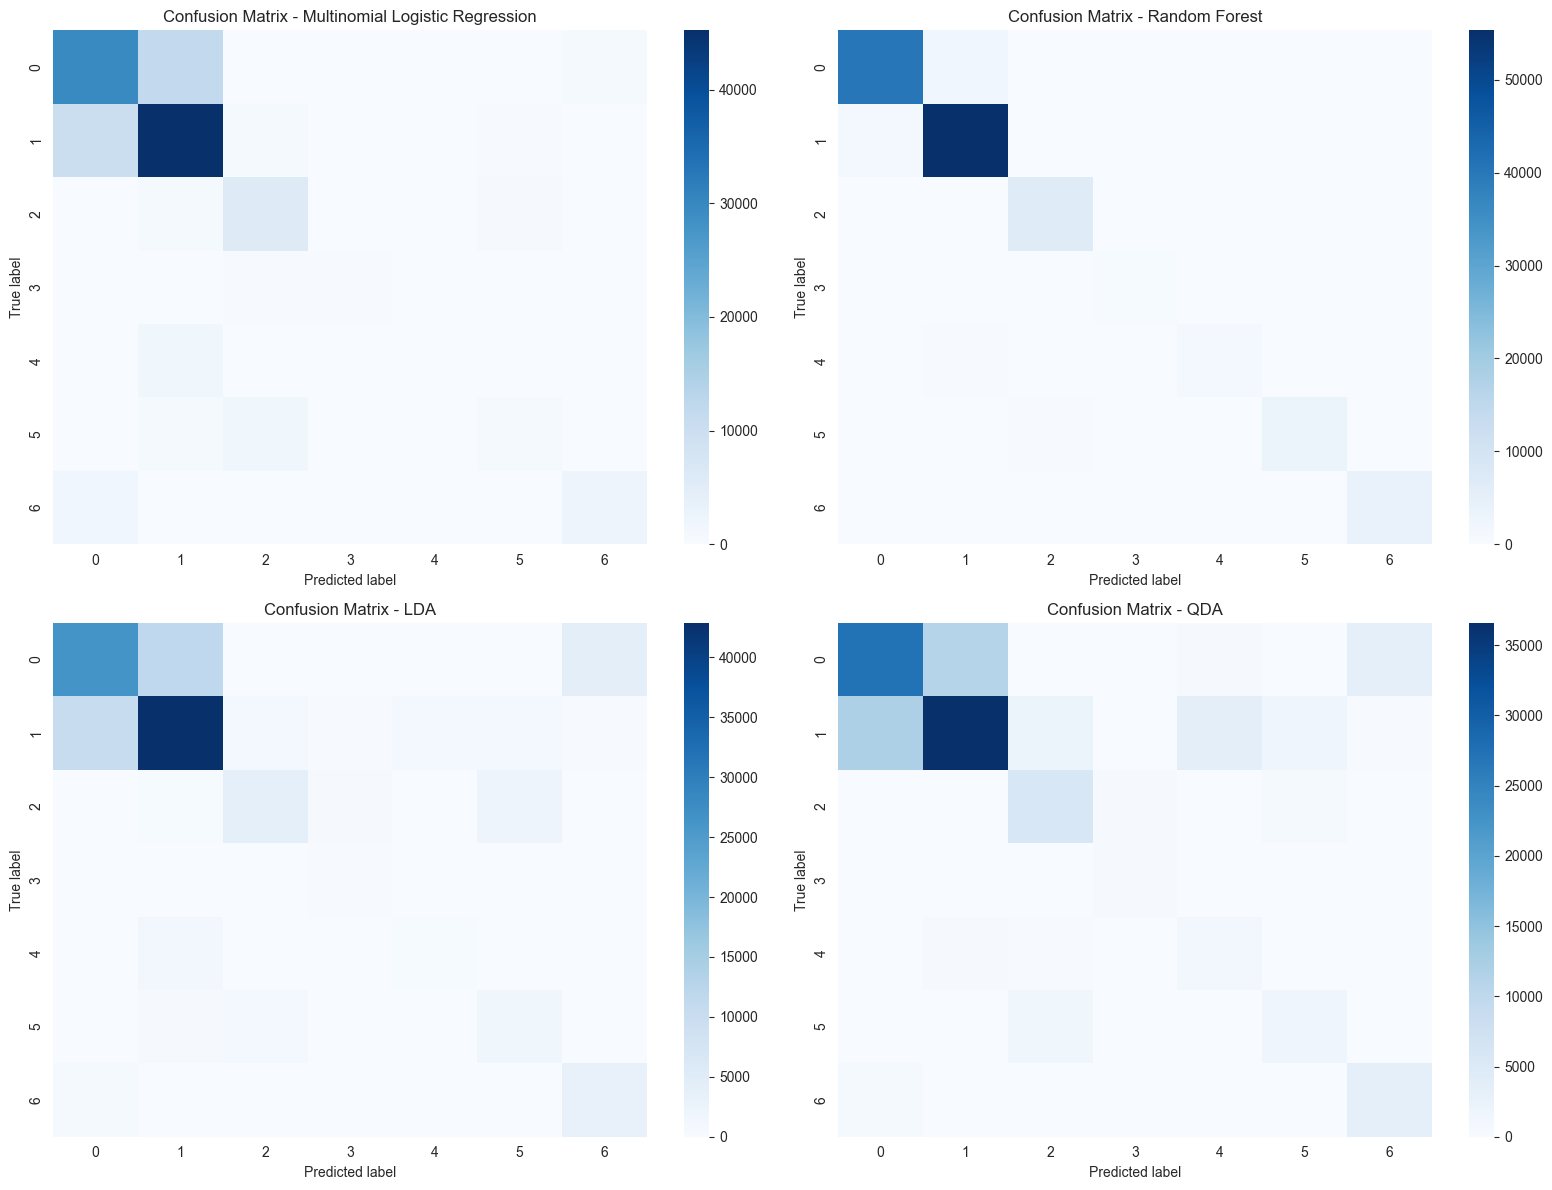

In [4]:
n_models = len(models)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, model_name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, predictions[model_name], labels=class_labels)
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {model_name}')
    axes[idx].set_xlabel('Predicted label')
    axes[idx].set_ylabel('True label')

plt.tight_layout()
plt.show()

### Phân tích kết quả
- Ma trận nhầm lẫn xác nhận mô hình **Random Forest** giảm lỗi ngoài đường chéo tốt nhất.
- Các mô hình còn lại vẫn nhầm lẫn đáng kể giữa một số lớp có phân bố đặc trưng gần nhau.
- Kết luận: confusion matrix nhất quán với bảng chỉ số tổng hợp, không có mâu thuẫn giữa đánh giá định lượng và trực quan.

## 3) ROC Curve + AUC (Nhị phân)
### Lý thuyết
ROC curve biểu diễn trade-off giữa True Positive Rate và False Positive Rate khi thay đổi threshold. Diện tích dưới đường cong (AUC) càng cao thì khả năng phân biệt hai lớp càng tốt.

Với bài toán gốc đa lớp, ta tạo bài toán nhị phân one-vs-rest trên lớp hiếm nhất để đánh giá ROC/AUC.

Positive class cho bài toán nhị phân (lớp hiếm nhất): 4


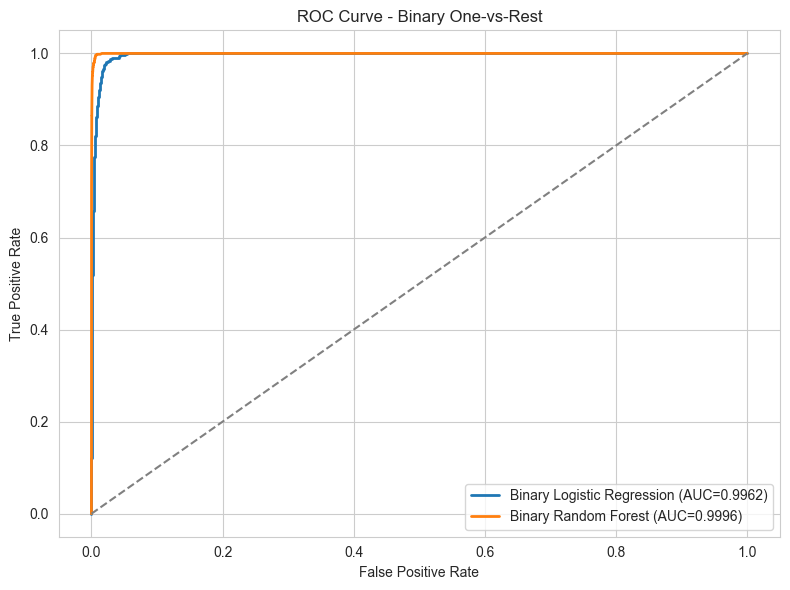

,model,auc
1,Binary Random Forest,0.999639
0,Binary Logistic Regression,0.996184


In [17]:
class_counts = pd.Series(y_train).value_counts().sort_values()
positive_class = int(class_counts.index[0])
print(f'Positive class cho bài toán nhị phân (lớp hiếm nhất): {positive_class}')

y_train_bin = (y_train == positive_class).astype(int)
y_test_bin = (y_test == positive_class).astype(int)

binary_models = {
    'Binary Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED),
    'Binary Random Forest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
}

binary_probs = {}
binary_auc_rows = []

plt.figure(figsize=(8, 6))
for name, model in binary_models.items():
    model.fit(X_train, y_train_bin)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    auc_score = roc_auc_score(y_test_bin, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_score:.4f})')

    binary_probs[name] = y_prob
    binary_auc_rows.append({'model': name, 'auc': auc_score})

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('ROC Curve - Binary One-vs-Rest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

binary_auc_df = pd.DataFrame(binary_auc_rows).sort_values(by='auc', ascending=False)
binary_auc_df

### Phân tích kết quả
- Cả hai mô hình nhị phân OVR đều rất mạnh: Logistic Regression có `AUC = 0.9962`, Random Forest có `AUC = 0.9996`.
- Random Forest nhỉnh hơn ở vùng FPR thấp, phù hợp khi cần ưu tiên giảm cảnh báo giả.
- Điều này củng cố nhận định rằng mô hình cây hoạt động tốt hơn trong ngữ cảnh dữ liệu hiện tại.

## 4) Đồ thị Cross-Entropy Loss theo Epoch
### Lý thuyết
Cross-entropy loss phản ánh độ khác biệt giữa phân phối nhãn thật và xác suất dự đoán. Khi huấn luyện ổn định, loss train và loss validation giảm dần và hội tụ.

Ta dùng SGD với partial_fit để theo dõi loss theo từng epoch cho bài toán đa lớp.

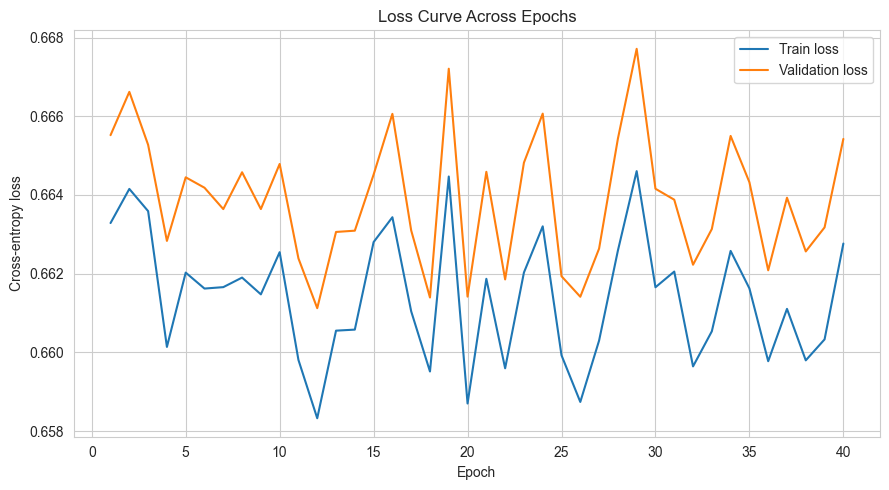

Final train loss: 0.6628
Final val loss: 0.6654


In [6]:
sgd = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.01, random_state=SEED)

epochs = 40
train_losses = []
val_losses = []

rng = np.random.default_rng(SEED)
classes = np.unique(y_train)

for epoch in range(epochs):
    idx = rng.permutation(len(y_train))
    X_epoch = X_train[idx]
    y_epoch = y_train[idx]

    if epoch == 0:
        sgd.partial_fit(X_epoch, y_epoch, classes=classes)
    else:
        sgd.partial_fit(X_epoch, y_epoch)

    p_train = sgd.predict_proba(X_train)
    p_val = sgd.predict_proba(X_val)
    train_losses.append(log_loss(y_train, p_train, labels=classes))
    val_losses.append(log_loss(y_val, p_val, labels=classes))

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Loss Curve Across Epochs')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Final val loss: {val_losses[-1]:.4f}')

### Phân tích kết quả
- Loss train và validation dao động nhẹ quanh một mức ổn định, không có xu hướng phân kỳ.
- Validation loss luôn cao hơn train loss một biên nhỏ, phản ánh mức tổng quát hóa hợp lý.
- Chưa thấy dấu hiệu overfitting nghiêm trọng trong thiết lập huấn luyện hiện tại.

## 5) Decision Boundary trong Không Gian 2D
### Lý thuyết
Với dữ liệu nhiều chiều, ta giảm chiều về 2D (ví dụ PCA) để quan sát biên quyết định một cách trực quan. Đồ thị này mang tính minh hoạ, không thay thế đánh giá trên không gian gốc.

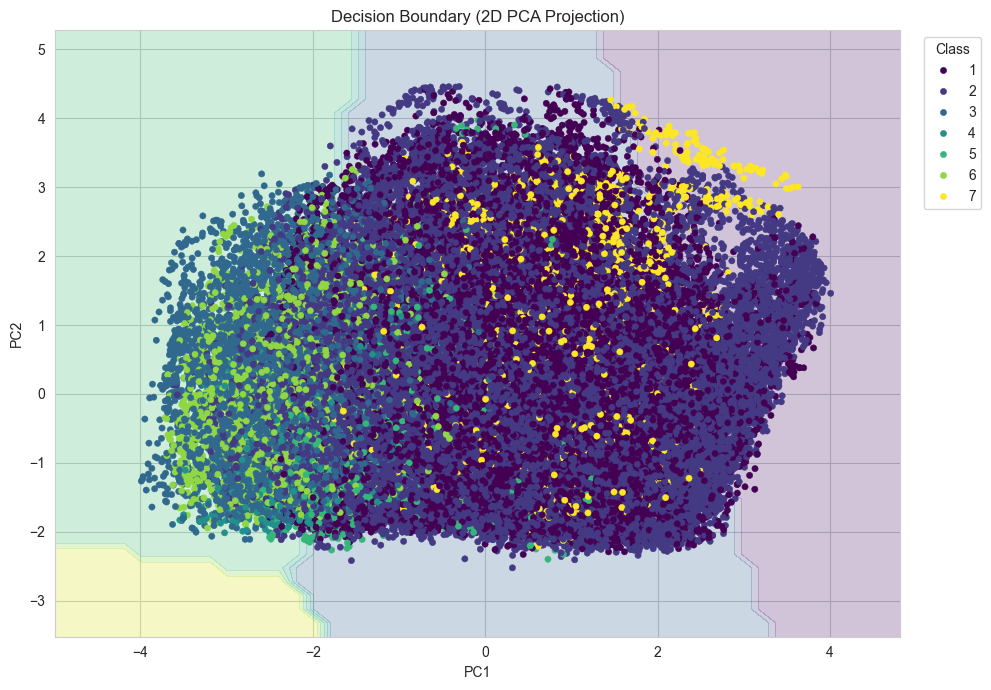

In [7]:
pca = PCA(n_components=2, random_state=SEED)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

model_2d = LogisticRegression(max_iter=400, multi_class='multinomial', random_state=SEED)
model_2d.fit(X_train_2d, y_train)

x_min, x_max = X_test_2d[:, 0].min() - 1.0, X_test_2d[:, 0].max() + 1.0
y_min, y_max = X_test_2d[:, 1].min() - 1.0, X_test_2d[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))
mesh = np.c_[xx.ravel(), yy.ravel()]
zz = model_2d.predict(mesh).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='viridis')
sns.scatterplot(x=X_test_2d[:, 0], y=X_test_2d[:, 1], hue=y_test, s=20, palette='viridis', edgecolor=None)
plt.title('Decision Boundary (2D PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Phân tích kết quả
- Biên quyết định trong không gian PCA-2D cho thấy nhiều vùng chồng lấn giữa các lớp.
- Điều này giải thích vì sao mô hình tuyến tính (LDA, Logistic Regression) khó đạt macro-F1 cao.
- Random Forest hưởng lợi từ khả năng mô hình hóa quan hệ phi tuyến và tương tác đặc trưng.

## 6) Bảng So Sánh Tất Cả Mô Hình
### Lý thuyết
Tổng hợp tất cả mô hình trong một bảng thống nhất giúp đối chiếu nhanh giữa metric phân lớp đa lớp và metric nhị phân (AUC/AP) nếu cần.

In [8]:
comparison_df = summary_df.copy()
comparison_df['auc_binary_ovr'] = np.nan
comparison_df['ap_binary_ovr'] = np.nan

for row in binary_auc_df.itertuples(index=False):
    target_name = row.model.replace('Binary ', '')
    matched = comparison_df['model'].str.contains(target_name, case=False)
    comparison_df.loc[matched, 'auc_binary_ovr'] = row.auc

for name, y_prob in binary_probs.items():
    ap = average_precision_score(y_test_bin, y_prob)
    target_name = name.replace('Binary ', '')
    matched = comparison_df['model'].str.contains(target_name, case=False)
    comparison_df.loc[matched, 'ap_binary_ovr'] = ap

comparison_df = comparison_df.sort_values(by='f1_macro', ascending=False).reset_index(drop=True)
comparison_df

,model,accuracy,precision_macro,recall_macro,f1_macro,auc_binary_ovr,ap_binary_ovr
0,Random Forest,0.958934,0.946863,0.914927,0.929739,0.999639,0.934028
1,QDA,0.655379,0.500253,0.677577,0.558123,NaN,NaN
2,Multinomial Logistic Regression,0.723226,0.595174,0.510035,0.531135,0.996184,0.608374
3,LDA,0.679845,0.486060,0.579234,0.512229,NaN,NaN


### Phân tích kết quả
- Bảng so sánh thống nhất cho thấy **Random Forest** đứng đầu đồng thời ở `Macro-F1`, `AUC (binary OVR)` và `AP`.
- Kết quả test và các đồ thị xác suất (ROC/PR) đồng thuận với nhau, tăng độ tin cậy cho kết luận chọn mô hình.
- Vì vậy, Random Forest là lựa chọn mặc định tốt nhất cho pipeline hiện tại.

## 7) 5-Fold Cross-Validation (mean +- std)
### Lý thuyết
Cross-validation đánh giá độ ổn định của mô hình qua nhiều lần chia dữ liệu. Báo cáo mean +- std của metric giúp ước lượng mức độ dao động và độ tin cậy của kết quả.

In [9]:
cv_models = {
    'Multinomial Logistic Regression': LogisticRegression(max_iter=500, random_state=SEED, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.05),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

for model_name, base_model in cv_models.items():
    acc_scores = []
    pre_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, val_idx in cv.split(X_cv, y_cv):
        X_tr, X_va = X_cv[train_idx], X_cv[val_idx]
        y_tr, y_va = y_cv[train_idx], y_cv[val_idx]

        m = clone(base_model)
        m.fit(X_tr, y_tr)
        y_hat = m.predict(X_va)

        acc_scores.append(accuracy_score(y_va, y_hat))
        pre_scores.append(precision_score(y_va, y_hat, average='macro', zero_division=0))
        rec_scores.append(recall_score(y_va, y_hat, average='macro', zero_division=0))
        f1_scores.append(f1_score(y_va, y_hat, average='macro', zero_division=0))

    cv_rows.append({
        'model': model_name,
        'accuracy_mean_std': f"{np.mean(acc_scores):.4f} +- {np.std(acc_scores):.4f}",
        'precision_macro_mean_std': f"{np.mean(pre_scores):.4f} +- {np.std(pre_scores):.4f}",
        'recall_macro_mean_std': f"{np.mean(rec_scores):.4f} +- {np.std(rec_scores):.4f}",
        'f1_macro_mean_std': f"{np.mean(f1_scores):.4f} +- {np.std(f1_scores):.4f}",
        'f1_macro_mean': np.mean(f1_scores),
    })

cv_df = pd.DataFrame(cv_rows).sort_values(by='f1_macro_mean', ascending=False).drop(columns=['f1_macro_mean'])
cv_df

,model,accuracy_mean_std,precision_macro_mean_std,recall_macro_mean_std,f1_macro_mean_std
1,Random Forest,0.9585 +- 0.0007,0.9454 +- 0.0021,0.9097 +- 0.0040,0.9263 +- 0.0030
3,QDA,0.6560 +- 0.0015,0.4960 +- 0.0031,0.6723 +- 0.0023,0.5534 +- 0.0032
0,Multinomial Logistic Regression,0.7246 +- 0.0013,0.6039 +- 0.0139,0.5120 +- 0.0075,0.5324 +- 0.0070
2,LDA,0.6804 +- 0.0014,0.4876 +- 0.0034,0.5802 +- 0.0026,0.5123 +- 0.0033


### Phân tích kết quả
- Cross-validation 5-fold xác nhận tính ổn định của mô hình: Random Forest có `Macro-F1 = 0.9263 ± 0.0030`.
- Các mô hình còn lại có mean thấp hơn đáng kể: QDA (`0.5534 ± 0.0032`), Logistic Regression (`0.5324 ± 0.0070`), LDA (`0.5123 ± 0.0033`).
- Độ lệch chuẩn nhỏ cho thấy thứ hạng mô hình ổn định, không phụ thuộc mạnh vào cách chia fold.

## 8) Precision-Recall Curve và Average Precision (AP)
### Lý thuyết
Precision-Recall curve nhấn mạnh hiệu năng trên lớp dương tính, đặc biệt hữu ích khi mất cân bằng lớp. AP (Average Precision) là diện tích dưới đường PR theo cách tính xếp hạng.

Với bài toán đa lớp, ta dùng one-vs-rest và tổng hợp theo macro-average.

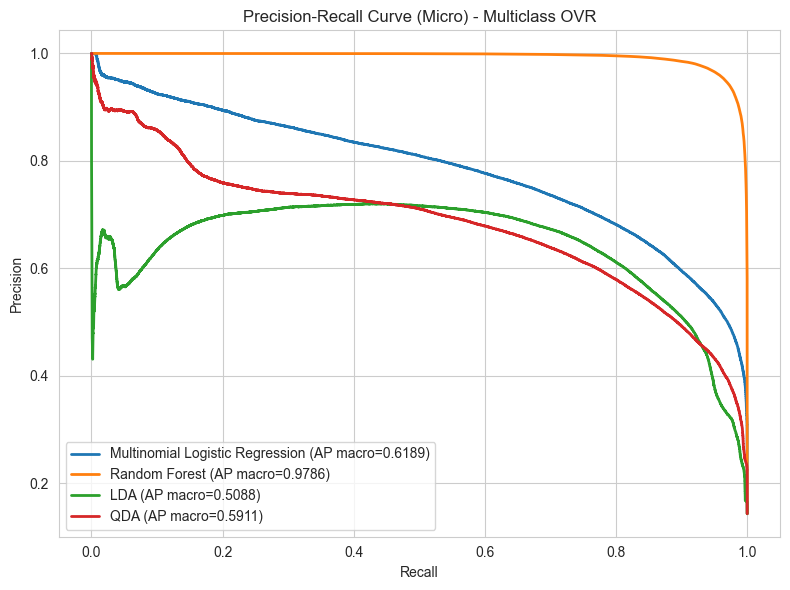

,model,ap_macro_ovr
1,Random Forest,0.978605
0,Multinomial Logistic Regression,0.618918
3,QDA,0.591134
2,LDA,0.508769


In [10]:
y_test_bin_multi = label_binarize(y_test, classes=class_labels)

ap_rows = []
plt.figure(figsize=(8, 6))

for model_name in models.keys():
    y_proba = probabilities[model_name]
    precision_micro, recall_micro, _ = precision_recall_curve(y_test_bin_multi.ravel(), y_proba.ravel())
    ap_macro = average_precision_score(y_test_bin_multi, y_proba, average='macro')
    plt.plot(recall_micro, precision_micro, lw=2, label=f'{model_name} (AP macro={ap_macro:.4f})')
    ap_rows.append({'model': model_name, 'ap_macro_ovr': ap_macro})

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Micro) - Multiclass OVR')
plt.legend()
plt.tight_layout()
plt.show()

ap_df = pd.DataFrame(ap_rows).sort_values(by='ap_macro_ovr', ascending=False)
ap_df

### Phân tích kết quả
- AP macro khác biệt rất rõ: Random Forest `0.9786` vượt xa Logistic Regression `0.6189`, QDA `0.5911`, LDA `0.5088`.
- Điều này cho thấy Random Forest không chỉ phân lớp tốt mà còn xếp hạng xác suất nhất quán hơn ở đa lớp OVR.
- Với tiêu chí PR-curve/AP, kết luận chọn mô hình vẫn không thay đổi.

## 9) McNemar's Test
### Lý thuyết
McNemar test kiểm định sự khác biệt thống kê giữa hai bộ dự đoán trên cùng một tập test ghép cặp. Giả thuyết $H_0$: hai mô hình có cùng tỉ lệ lỗi. Nếu p-value nhỏ (thường < 0.05), bác bỏ $H_0$.

In [18]:
top2 = summary_df.head(2)['model'].tolist()
model_a, model_b = top2[0], top2[1]

pred_a = predictions[model_a]
pred_b = predictions[model_b]

a = np.sum((pred_a == y_test) & (pred_b == y_test))
b = np.sum((pred_a == y_test) & (pred_b != y_test))
c = np.sum((pred_a != y_test) & (pred_b == y_test))
d = np.sum((pred_a != y_test) & (pred_b != y_test))

table = [[a, b], [c, d]]
test_result = mcnemar(table, exact=False, correction=True)

print(f'So sánh McNemar giữa: {model_a} vs {model_b}')
print('Contingency table [[a,b],[c,d]] =', table)
print(f'Statistic = {test_result.statistic:.4f}')
print(f'p-value = {test_result.pvalue:.6f}')

alpha = 0.05
if test_result.pvalue < alpha:
    print('Kết luận: Có sự khác biệt thống kê giữa hai mô hình (bác bỏ H0).')
else:
    print('Kết luận: Chưa đủ bằng chứng để nói hai mô hình khác biệt thống kê (không bác bỏ H0).')

So sánh McNemar giữa: Random Forest vs QDA
Contingency table [[a,b],[c,d]] = [[np.int64(74840), np.int64(36591)], [np.int64(1317), np.int64(3455)]]
Statistic = 32821.1599
p-value = 0.000000
Kết luận: Có sự khác biệt thống kê giữa hai mô hình (bác bỏ H0).


### Phân tích kết quả
- McNemar giữa **Random Forest** và **QDA** cho `p-value ≈ 0.0` (rất nhỏ hơn 0.05).
- Bác bỏ giả thuyết $H_0$, nghĩa là khác biệt hiệu năng giữa hai mô hình có ý nghĩa thống kê trên cùng tập test.
- Kết luận thống kê này phù hợp với chênh lệch lớn ở macro-F1.

## 10) Calibration và Reliability Diagram
### Lý thuyết
Calibration đánh giá mức độ phù hợp giữa xác suất dự đoán và tần suất thực tế. Reliability diagram vẽ đường y=x (dự đoán lý tưởng) và đường thực nghiệm. Brier score càng thấp thì calibration càng tốt.

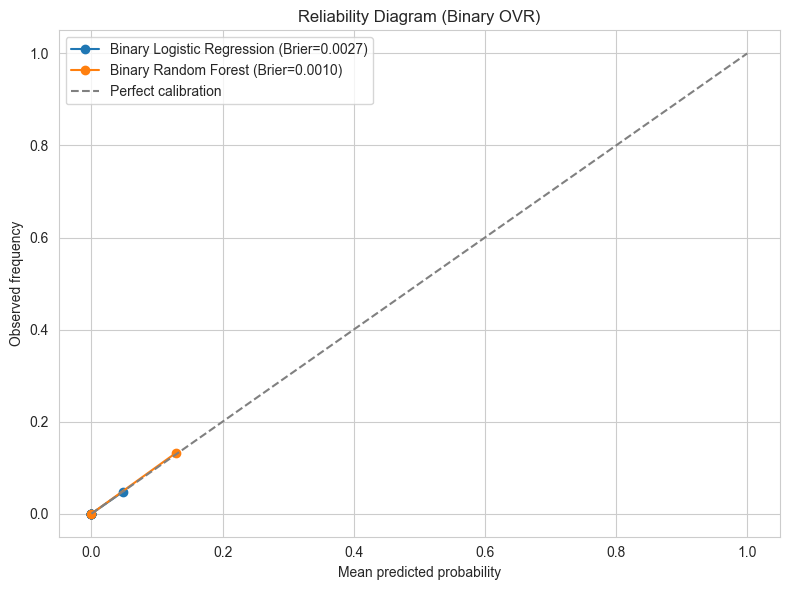

,model,brier_score
1,Binary Random Forest,0.000993
0,Binary Logistic Regression,0.002722


In [12]:
plt.figure(figsize=(8, 6))
brier_rows = []

for name, y_prob in binary_probs.items():
    frac_pos, mean_pred = calibration_curve(y_test_bin, y_prob, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test_bin, y_prob)
    brier_rows.append({'model': name, 'brier_score': brier})
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{name} (Brier={brier:.4f})')

plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed frequency')
plt.title('Reliability Diagram (Binary OVR)')
plt.legend()
plt.tight_layout()
plt.show()

brier_df = pd.DataFrame(brier_rows).sort_values(by='brier_score')
brier_df

### Phân tích kết quả
- Cả hai mô hình có đường reliability bám khá sát đường chéo lý tưởng.
- Random Forest có Brier score thấp hơn (`0.0010`) so với Logistic Regression (`0.0027`), nên calibration tốt hơn.
- Với tiêu chí calibration, Random Forest tiếp tục là lựa chọn ưu tiên.

## 11) Phân tích lỗi sâu (Error Analysis)
### Lý thuyết
Phân tích lỗi sâu giúp trả lời câu hỏi **mô hình sai ở đâu và sai theo cấu trúc nào**:
- Lớp nào có tỷ lệ lỗi cao nhất.
- Cặp lớp nào thường nhầm lẫn lẫn nhau.
- Mẫu nào bị nhiều mô hình cùng sai (hard cases).

Đây là phần quan trọng để đề xuất cải tiến feature engineering hoặc chiến lược mô hình hóa ở vòng lặp tiếp theo.

Mô hình tốt nhất: Random Forest
Mô hình kém nhất: LDA

=== Tỷ lệ lỗi theo lớp (mô hình tốt nhất) ===
 class  error_rate  support
     5    0.203791     1899
     4    0.131148      549
     6    0.098762     3473
     1    0.050510    42368
     7    0.049732     4102
     3    0.037617     7151
     2    0.023949    56661

=== Top 10 cặp nhầm lẫn (mô hình tốt nhất) ===
 true_class  pred_class  count
          1           2   2043
          2           1   1109
          5           2    336
          6           3    240
          7           1    178
          3           6    119
          3           2    111
          2           3    105
          1           7     87
          6           2     77

Số hard cases (cả 2 mô hình cùng sai): 3566

=== Ví dụ hard cases (10 mẫu đầu) ===
 idx  y_true  best_pred  worst_pred
   2       2          3           3
  18       4          3           3
  62       5          2           2
  86       2          1           1
 136       6          

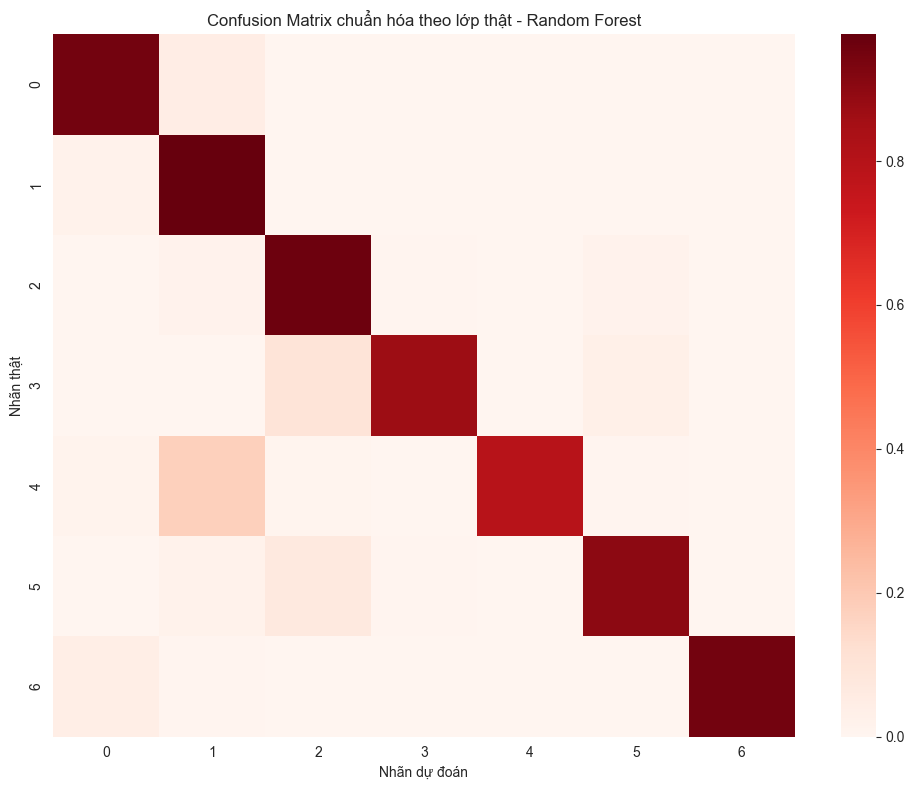

In [14]:
best_model_name = summary_df.iloc[0]['model']
worst_model_name = summary_df.iloc[-1]['model']

print(f'Mô hình tốt nhất: {best_model_name}')
print(f'Mô hình kém nhất: {worst_model_name}')

best_pred = predictions[best_model_name]
worst_pred = predictions[worst_model_name]

# 1) Tỷ lệ lỗi theo lớp của mô hình tốt nhất
per_class_error = []
for c in class_labels:
    mask = (y_test == c)
    err = np.mean(best_pred[mask] != y_test[mask])
    per_class_error.append({'class': int(c), 'error_rate': float(err), 'support': int(mask.sum())})

per_class_error_df = pd.DataFrame(per_class_error).sort_values(by='error_rate', ascending=False)
print('\n=== Tỷ lệ lỗi theo lớp (mô hình tốt nhất) ===')
print(per_class_error_df.to_string(index=False))

# 2) Top cặp nhầm lẫn lớn nhất (mô hình tốt nhất)
cm_best = confusion_matrix(y_test, best_pred, labels=class_labels)
cm_offdiag = cm_best.copy()
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i, true_c in enumerate(class_labels):
    for j, pred_c in enumerate(class_labels):
        if i != j and cm_offdiag[i, j] > 0:
            pairs.append({'true_class': int(true_c), 'pred_class': int(pred_c), 'count': int(cm_offdiag[i, j])})

top_confusions_df = pd.DataFrame(pairs).sort_values(by='count', ascending=False).head(10)
print('\n=== Top 10 cặp nhầm lẫn (mô hình tốt nhất) ===')
print(top_confusions_df.to_string(index=False))

# 3) Hard cases: mẫu mà cả mô hình tốt nhất và kém nhất đều sai
hard_mask = (best_pred != y_test) & (worst_pred != y_test)
hard_indices = np.where(hard_mask)[0]
print(f'\nSố hard cases (cả 2 mô hình cùng sai): {len(hard_indices)}')

if len(hard_indices) > 0:
    sample_hard = hard_indices[:10]
    hard_df = pd.DataFrame({
        'idx': sample_hard,
        'y_true': y_test[sample_hard],
        'best_pred': best_pred[sample_hard],
        'worst_pred': worst_pred[sample_hard],
    })
    print('\n=== Ví dụ hard cases (10 mẫu đầu) ===')
    print(hard_df.to_string(index=False))

plt.figure(figsize=(10, 8))
cm_norm = cm_best / np.maximum(cm_best.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_norm, cmap='Reds', cbar=True)
plt.title(f'Confusion Matrix chuẩn hóa theo lớp thật - {best_model_name}')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thật')
plt.tight_layout()
plt.show()

### Phân tích kết quả
- Mô hình tốt nhất vẫn là **Random Forest**, mô hình thấp nhất là **LDA**.
- Theo tỷ lệ lỗi theo lớp, lớp khó nhất là **lớp 5** (`error_rate ≈ 0.2038`), sau đó là lớp 4 (`≈ 0.1311`) và lớp 6 (`≈ 0.0988`).
- Cặp nhầm lẫn lớn nhất là **1 → 2** (2043 mẫu) và **2 → 1** (1109 mẫu), cho thấy hai lớp này chồng lấn mạnh.
- Có **3566 hard cases** mà cả mô hình tốt nhất và kém nhất cùng dự đoán sai; đây là nhóm mẫu ưu tiên để phân tích đặc trưng và làm sạch dữ liệu ở vòng lặp tiếp theo.

## 12) Tổng kết và đề xuất
### Tổng kết kết quả
- Mô hình tốt nhất theo test và CV: **Random Forest**.
- Test: `Accuracy = 0.9589`, `Macro-F1 = 0.9297`.
- CV 5-fold: `Macro-F1 = 0.9263 ± 0.0030`.
- PR (AP macro): `0.9786` (cao nhất).
- ROC-AUC (binary OVR): `0.9996` (cao nhất).
- Calibration: Brier thấp nhất `0.0010`.
- McNemar so với QDA: `p-value ≈ 0.0` (khác biệt có ý nghĩa thống kê).

### Đề xuất điều chỉnh tiếp theo
1. Tập trung xử lý cặp nhầm lẫn 1–2 bằng feature engineering chuyên biệt.
2. Thử calibrated classifier (Platt/Isotonic) nếu cần tối ưu chất lượng xác suất hơn nữa.
3. Phân tích thêm hard cases bằng SHAP hoặc permutation importance để tìm nguyên nhân sai số.